In [ ]:
# ── CONFIG ───────────────────────────────────────────────────────────────────
KAGGLE_TOKEN        = ''
REPO_URL            = 'git@github.com:xSurus/CIL_Monocular_depth.git'
BRANCH              = 'master'
FORCE_RECOMPUTE_VEG = False

# ── PATHS — Drive ─────────────────────────────────────────────────────────────
DRIVE_BASE          = '/content/drive/MyDrive/CIL'
DRIVE_CLIP          = f'{DRIVE_BASE}/data/clip_scores'
DRIVE_OVERGROWN_ZIP = f'{DRIVE_BASE}/data/overgrown_train.zip'

# ── PATHS — Local ─────────────────────────────────────────────────────────────
DATA_LOCAL    = '/content/data'
CLIP_LOCAL    = f'{DATA_LOCAL}/clip_scores'
OVERGROWN_DIR = f'{DATA_LOCAL}/monodepth_kaggle2026/overgrown'
TRAIN_DIR     = f'{DATA_LOCAL}/monodepth_kaggle2026/train'
TEST_DIR      = f'{DATA_LOCAL}/monodepth_kaggle2026/test'

In [ ]:
!pip install -q transformers timm umap-learn scikit-learn seaborn kaggle

import os, sys, glob
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import timm
import umap.umap_ as umap
from PIL import Image
from tqdm import tqdm
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics.pairwise import cosine_similarity
import torch.nn.functional as F
import warnings

warnings.filterwarnings("ignore")
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Kaggle dataset
if not os.path.exists(f'{DATA_LOCAL}/monodepth_kaggle2026'):
    os.environ['KAGGLE_API_TOKEN'] = KAGGLE_TOKEN
    !kaggle competitions download -c ethz-cil-monocular-depth-estimation-2026 -p /content/
    !unzip -q /content/ethz-cil-monocular-depth-estimation-2026.zip -d {DATA_LOCAL}
    !rm /content/ethz-cil-monocular-depth-estimation-2026.zip
else:
    print(f"Warning: {DATA_LOCAL}/monodepth_kaggle2026 already exists.")
# Drive
from google.colab import drive
drive.mount('/content/drive')

# Overgrown dataset
_local_zip = '/content/train_overgrown_dataset.zip'
if os.path.exists(DRIVE_OVERGROWN_ZIP):
    print("Copying overgrown dataset from Google Drive...")
    !cp "{DRIVE_OVERGROWN_ZIP}" "{_local_zip}"
else:
    print(f"Warning: Could not find {DRIVE_OVERGROWN_ZIP} in your Google Drive.")

os.makedirs(OVERGROWN_DIR, exist_ok=True)
if os.path.exists(_local_zip) and not os.listdir(OVERGROWN_DIR):
    !unzip -q {_local_zip} -d {OVERGROWN_DIR}
    print(f"Unzipped Overgrown Dataset to {OVERGROWN_DIR}")

def get_image_paths(directory):
    paths = glob.glob(os.path.join(directory, '**', '*.*'), recursive=True)
    valid_exts = ('.jpg', '.jpeg', '.png', '.bmp', '.webp')
    return sorted([p for p in paths if p.lower().endswith(valid_exts) and '_rgb' in p])

train_paths = get_image_paths(TRAIN_DIR)
test_paths  = get_image_paths(TEST_DIR)
overgrown_paths = get_image_paths(OVERGROWN_DIR)

print(f"Loaded: {len(train_paths)} Train | {len(test_paths)} Test | {len(overgrown_paths)} Overgrown images.")

In [ ]:
# 2. SSH key — first time: generates and saves to Drive; every session: loads from Drive
import os
if not os.path.exists('/gdrive/MyDrive/CIL/id_ed25519'):
    !mkdir -p /root/.ssh /gdrive/MyDrive/CIL
    !ssh-keygen -t ed25519 -C 'colab' -f /root/.ssh/id_ed25519 -N '' -q
    !cp /root/.ssh/id_ed25519 /gdrive/MyDrive/CIL/id_ed25519
    !cp /root/.ssh/id_ed25519.pub /gdrive/MyDrive/CIL/id_ed25519.pub
    print('*** Add this key to github.com/settings/keys, then re-run this cell ***')
    !cat /root/.ssh/id_ed25519.pub
else:
    !mkdir -p /root/.ssh
    !cp /gdrive/MyDrive/CIL/id_ed25519 /root/.ssh/id_ed25519
    !cp /gdrive/MyDrive/CIL/id_ed25519.pub /root/.ssh/id_ed25519.pub
    !chmod 600 /root/.ssh/id_ed25519
    !ssh-keyscan github.com >> /root/.ssh/known_hosts 2>/dev/null
    print('SSH key loaded from Drive.')

In [ ]:
# 3. Clone / pull repo
import importlib
if not os.path.exists('/content/CIL_Monocular_depth'):
    !git clone -b {BRANCH} {REPO_URL} /content/CIL_Monocular_depth
else:
    !git -C /content/CIL_Monocular_depth remote set-url origin {REPO_URL}
    !git -C /content/CIL_Monocular_depth fetch origin
    !git -C /content/CIL_Monocular_depth reset --hard origin/{BRANCH}
%cd /content/CIL_Monocular_depth
sys.path.insert(0, '/content/CIL_Monocular_depth')
importlib.invalidate_caches()
if 'tools.colab_notebook_utils' in sys.modules:
    import tools.colab_notebook_utils as _cnu
    importlib.reload(_cnu)
!pip install -q timm


# Train and Test Set Distributions into Areal, Buildings and Vegetation Categories.

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

The image processor of type `CLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json:   0%|          | 0.00/4.52k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/905 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/961k [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.71G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/590 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-large-patch14
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Test Images: 100%|██████████| 591/591 [00:26<00:00, 22.59it/s]


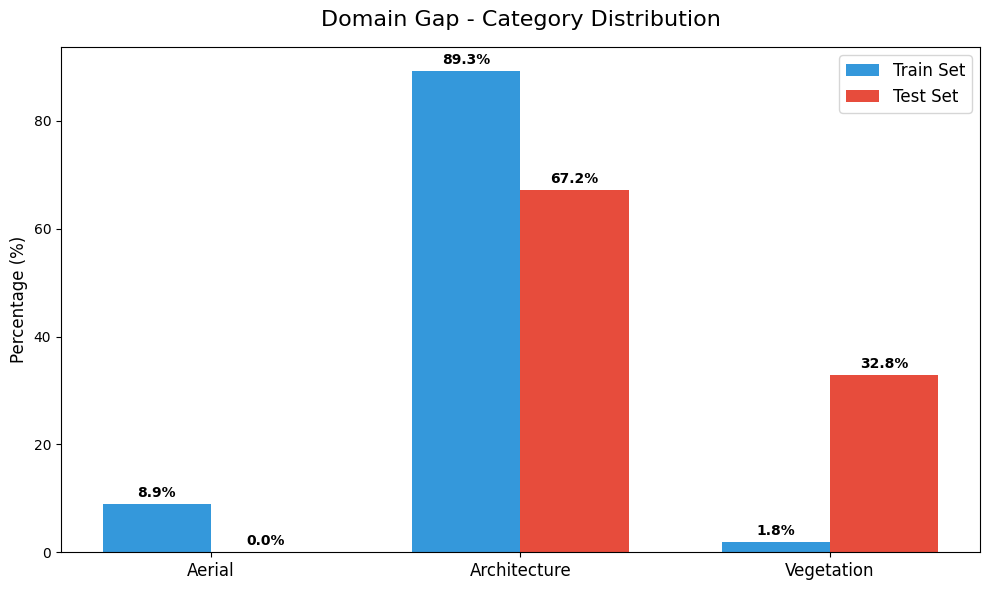

In [ ]:
from transformers import CLIPProcessor, CLIPModel

clip_model_id = "openai/clip-vit-large-patch14"
clip_processor = CLIPProcessor.from_pretrained(clip_model_id)
clip_model = CLIPModel.from_pretrained(clip_model_id).to(DEVICE).eval()

categories = ["Aerial", "Architecture", "Vegetation"]
text_prompts = [
    "An aerial view looking down from far away",
    "A photo dominated by buildings and architecture",
    "A photo heavily featuring trees, bushes, and vegetation"
]

@torch.no_grad()
def classify_images(image_paths, desc):
    results = {cat: 0 for cat in categories}
    for img_path in tqdm(image_paths, desc=desc):
        try:
            image = Image.open(img_path).convert('RGB')
            inputs = clip_processor(text=text_prompts, images=image, return_tensors="pt", padding=True)
            inputs = {k: v.to(DEVICE) for k, v in inputs.items()}
            probs = clip_model(**inputs).logits_per_image.softmax(dim=1).cpu().numpy()[0]
            results[categories[np.argmax(probs)]] += 1
        except Exception: continue
    return results

train_dist = classify_images(train_paths, "Train Images")
test_dist = classify_images(test_paths, "Test Images")

del clip_model, clip_processor
torch.cuda.empty_cache()

def plot_image_distribution(train_dist, test_dist):
    labels = list(train_dist.keys())
    train_counts = list(train_dist.values())
    test_counts = list(test_dist.values())

    train_pct = [c / sum(train_counts) * 100 for c in train_counts]
    test_pct = [c / sum(test_counts) * 100 for c in test_counts]

    x = np.arange(len(labels))
    width = 0.35

    fig, ax = plt.subplots(figsize=(10, 6))
    bars1 = ax.bar(x - width/2, train_pct, width, label='Train Set', color='#3498db')
    bars2 = ax.bar(x + width/2, test_pct, width, label='Test Set', color='#e74c3c')

    ax.set_ylabel('Percentage (%)', fontsize=12)
    ax.set_title('Domain Gap - Category Distribution', fontsize=16, pad=15)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=12)
    ax.legend(fontsize=12)

    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.annotate(f'{height:.1f}%', xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontweight='bold')
    plt.tight_layout()
    plt.show()

plot_image_distribution(train_dist, test_dist)

# Train Set Valid Depth Pixel Distribution into Vegetation, Buildings and Other

preprocessor_config.json:   0%|          | 0.00/271 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/6.89k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/339M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/1172 [00:00<?, ?it/s]

Pixel Analysis:   0%|          | 0/22605 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/339M [00:00<?, ?B/s]

Pixel Analysis: 100%|██████████| 22605/22605 [35:52<00:00, 10.50it/s]


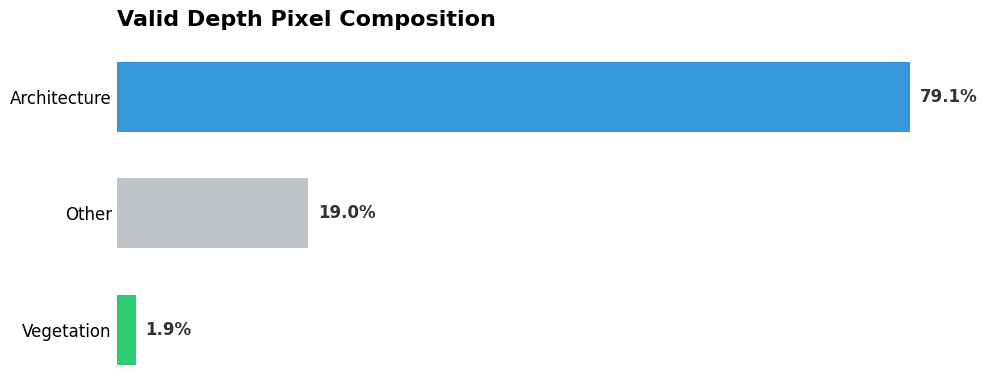

In [ ]:
from transformers import SegformerImageProcessor, SegformerForSemanticSegmentation
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from PIL import Image
from tqdm import tqdm

seg_model_id = "nvidia/segformer-b5-finetuned-ade-640-640"
seg_extractor = SegformerImageProcessor.from_pretrained(seg_model_id)
seg_model = SegformerForSemanticSegmentation.from_pretrained(seg_model_id).to(DEVICE).eval()

VEGETATION_IDS = {4, 9, 17, 66}
ARCHITECTURE_IDS = {0, 1, 25, 32}

def get_valid_depth_mask(img_path, target_shape):
    depth_path = img_path.replace('_rgb.png', '_depth.npy')
    try:
        depth_map = np.load(depth_path)
        valid_mask = (depth_map >= 0.001) & (depth_map <= 80) & (~np.isnan(depth_map))
        return valid_mask if valid_mask.shape == target_shape else np.zeros(target_shape, dtype=bool)
    except Exception: return np.zeros(target_shape, dtype=bool)

@torch.no_grad()
def analyze_valid_pixels(image_paths, limit=500):
    paths = image_paths[:limit] if limit else image_paths
    pixel_counts = {"Architecture": 0, "Vegetation": 0, "Other": 0}

    for img_path in tqdm(paths, desc="Pixel Analysis"):
        try:
            image = Image.open(img_path).convert('RGB')
            orig_size = (image.height, image.width)

            inputs = {k: v.to(DEVICE) for k, v in seg_extractor(images=image, return_tensors="pt").items()}
            logits = seg_model(**inputs).logits
            pred_mask = F.interpolate(logits, size=orig_size, mode="bilinear", align_corners=False).argmax(dim=1).squeeze().cpu().numpy()

            valid_mask = get_valid_depth_mask(img_path, orig_size)
            valid_pixels = pred_mask[valid_mask]

            veg_count = np.isin(valid_pixels, list(VEGETATION_IDS)).sum()
            arch_count = np.isin(valid_pixels, list(ARCHITECTURE_IDS)).sum()

            pixel_counts["Vegetation"] += veg_count
            pixel_counts["Architecture"] += arch_count
            pixel_counts["Other"] += len(valid_pixels) - (veg_count + arch_count)
        except Exception: continue
    return pixel_counts

pixel_dist = analyze_valid_pixels(train_paths, limit=None)

del seg_model, seg_extractor
torch.cuda.empty_cache()

def plot_pixel_distribution(dist):
    total_pixels = sum(dist.values())
    if total_pixels == 0: total_pixels = 1

    sorted_dist = sorted(dist.items(), key=lambda x: x[1])
    labels = [item[0] for item in sorted_dist]
    percentages = [(item[1] / total_pixels) * 100 for item in sorted_dist]

    color_map = {'Architecture': '#3498db', 'Vegetation': '#2ecc71', 'Other': '#bdc3c7'}
    colors = [color_map[label] for label in labels]

    fig, ax = plt.subplots(figsize=(10, 4))
    bars = ax.barh(labels, percentages, color=colors, height=0.6)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.set_xticks([])
    ax.tick_params(axis='y', length=0, labelsize=12)

    for bar in bars:
        width = bar.get_width()
        ax.text(width + 1, bar.get_y() + bar.get_height()/2, f'{width:.1f}%',
                va='center', ha='left', fontsize=12, fontweight='bold', color='#333')

    plt.title("Valid Depth Pixel Composition", fontsize=16, fontweight='bold', loc='left', pad=15)
    plt.tight_layout()
    plt.show()

plot_pixel_distribution(pixel_dist)

# Extracting DINOv2 Embeddings from Train, Test and Overgrown Set


In [ ]:
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader
import timm
import torch
import numpy as np
from tqdm import tqdm
from PIL import Image

dino_transforms = T.Compose([
    T.Resize((560, 560), interpolation=T.InterpolationMode.BICUBIC),
    T.ToTensor(),
    T.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
])

class ImageDataset(Dataset):
    def __init__(self, paths): self.paths = paths
    def __len__(self): return len(self.paths)
    def __getitem__(self, idx):
        try: return dino_transforms(Image.open(self.paths[idx]).convert('RGB'))
        except: return torch.zeros((3, 560, 560))

dino = timm.create_model('vit_large_patch14_dinov2.lvd142m', pretrained=True, img_size=560, dynamic_img_size=True, num_classes=0).to(DEVICE).eval()

@torch.no_grad()
def get_embeddings(paths, desc):
    loader = DataLoader(ImageDataset(paths), batch_size=32, num_workers=2)
    embs = []
    with torch.autocast(device_type="cuda" if "cuda" in DEVICE else "cpu", dtype=torch.float16):
        for batch in tqdm(loader, desc=desc):
            embs.append(dino(batch.to(DEVICE)).cpu().numpy())
    return np.vstack(embs) if embs else np.array([])

train_embs = get_embeddings(train_paths, "Train Embeddings")
test_embs = get_embeddings(test_paths, "Test Embeddings")
overgrown_embs = get_embeddings(overgrown_paths, "Overgrown Embeddings")

del dino
torch.cuda.empty_cache()

model.safetensors:   0%|          | 0.00/1.22G [00:00<?, ?B/s]

Overgrown Embeddings: 100%|██████████| 126/126 [00:39<00:00,  3.15it/s]


# Clustering the DINOv2 Embeddings of the Test Set into three clusters

In [ ]:
from sklearn.cluster import KMeans
import umap.umap_ as umap

kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')
test_labels = kmeans.fit_predict(test_embs)

all_embs = np.vstack([train_embs, overgrown_embs, test_embs])

reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
all_2d = reducer.fit_transform(all_embs)

len_train = len(train_embs)
len_overgrown = len(overgrown_embs)

train_2d = all_2d[:len_train]
overgrown_2d = all_2d[len_train : len_train + len_overgrown]
test_2d = all_2d[len_train + len_overgrown:]

# Visualize UMAP and Test Set Clusters

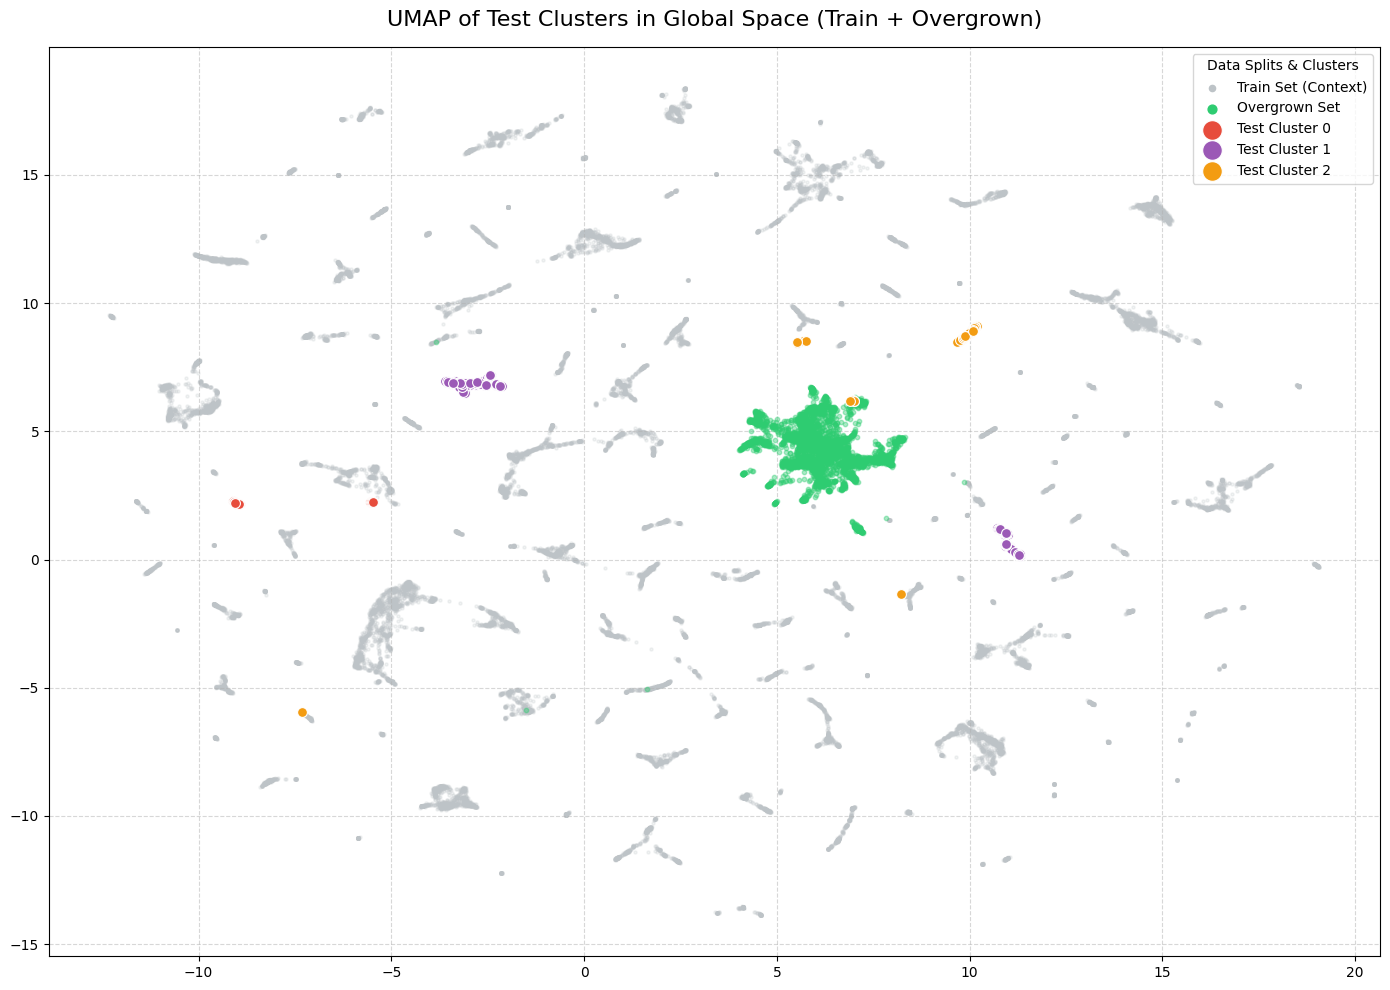

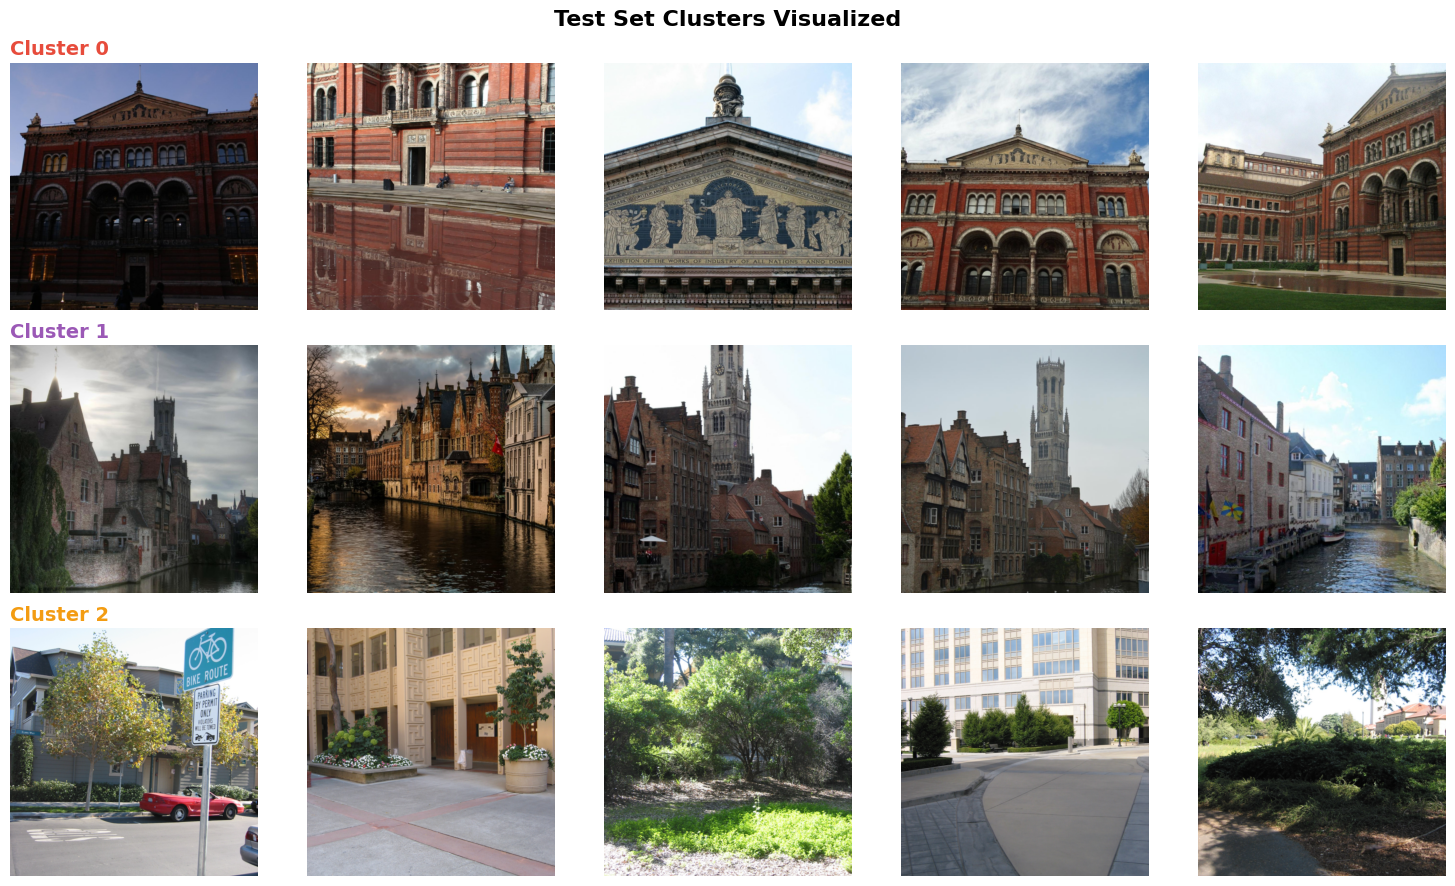

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 10))

plt.scatter(train_2d[:, 0], train_2d[:, 1], c='#bdc3c7', s=5, alpha=0.2, label='Train Set (Context)', zorder=1)

if len(overgrown_2d) > 0:
    plt.scatter(overgrown_2d[:, 0], overgrown_2d[:, 1], c='#2ecc71', s=10, alpha=0.4, label='Overgrown Set', zorder=2)

test_colors = ['#e74c3c', '#9b59b6', '#f39c12']
for i in range(3):
    mask = test_labels == i
    plt.scatter(
        test_2d[mask, 0], test_2d[mask, 1],
        c=test_colors[i],
        s=50,
        alpha=1.0,
        edgecolor='white',
        linewidth=0.8,
        label=f'Test Cluster {i}',
        zorder=3 + i
    )

plt.title("UMAP of Test Clusters in Global Space (Train + Overgrown)", fontsize=16, pad=15)

legend = plt.legend(title="Data Splits & Clusters", markerscale=2, loc="best")
for lh in legend.legend_handles:
    lh.set_alpha(1)

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(3, 5, figsize=(15, 9))
fig.suptitle("Test Set Clusters Visualized", fontsize=16, fontweight='bold')

for i in range(3):
    cluster_idx = np.where(test_labels == i)[0]
    samples = np.random.choice(cluster_idx, min(5, len(cluster_idx)), replace=False)

    for j, idx in enumerate(samples):
        axes[i, j].imshow(Image.open(test_paths[idx]))
        axes[i, j].axis('off')
        if j == 0:
            # Color-code the row titles to match the UMAP map
            axes[i, j].set_title(f"Cluster {i}", fontsize=14, loc='left', color=test_colors[i], fontweight='bold')

plt.tight_layout()
plt.show()

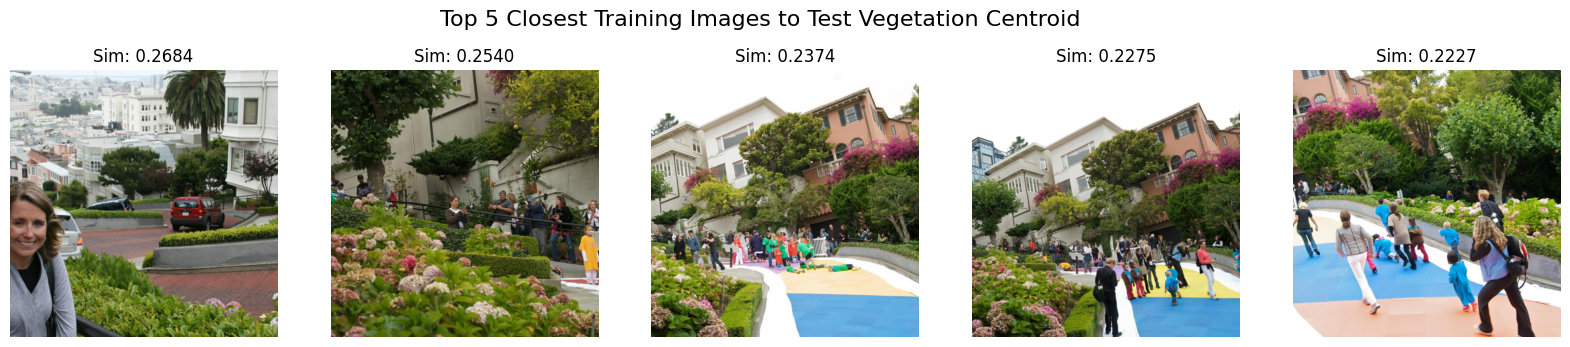

In [ ]:
VEG_CLUSTER_ID = 2

veg_test_embs = test_embs[test_labels == VEG_CLUSTER_ID]
veg_centroid = np.mean(veg_test_embs, axis=0).reshape(1, -1)

similarities = cosine_similarity(train_embs, veg_centroid).flatten()
top_indices = np.argsort(similarities)[-5:][::-1]

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
fig.suptitle("Top 5 Closest Training Images to Test Vegetation Centroid", fontsize=16)
for i, idx in enumerate(top_indices):
    axes[i].imshow(Image.open(train_paths[idx]))
    axes[i].set_title(f"Sim: {similarities[idx]:.4f}", fontsize=12)
    axes[i].axis('off')
plt.show()

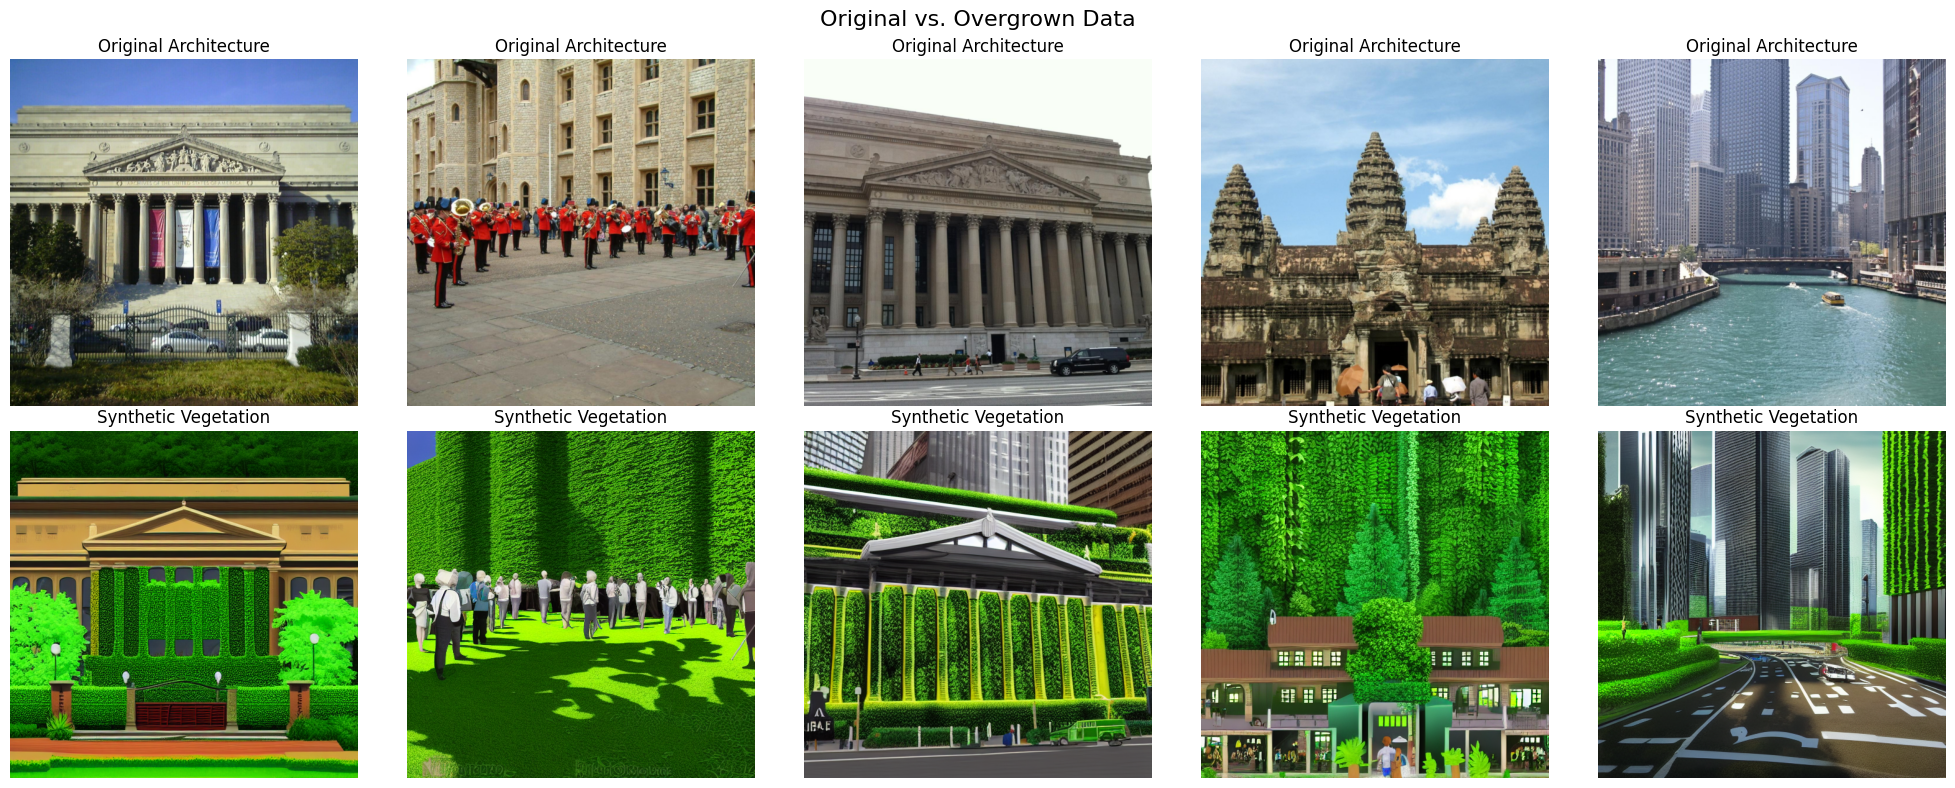

In [ ]:
import random

if len(overgrown_paths) == 0:
    print("Overgrown paths not found")
else:
    samples = random.sample(overgrown_paths, min(5, len(overgrown_paths)))

    fig, axes = plt.subplots(2, 5, figsize=(20, 8))
    fig.suptitle("Original vs. Overgrown Data", fontsize=16)

    for i, over_path in enumerate(samples):
        base_name = os.path.basename(over_path).replace("_overgrown_rgb.png", "_rgb.png")
        orig_path = os.path.join(TRAIN_DIR, base_name)

        try: axes[0, i].imshow(Image.open(orig_path))
        except: pass
        axes[0, i].set_title("Original Architecture", fontsize=12)
        axes[0, i].axis('off')

        axes[1, i].imshow(Image.open(over_path))
        axes[1, i].set_title("Synthetic Vegetation", fontsize=12)
        axes[1, i].axis('off')

    plt.tight_layout()
    plt.show()

# We show that the Overgrown Data is close to the vegetation cluster of the test set

Top 50 Nearest Neighbors to Centroid: 80.0% are Overgrown data.
Average Nearest Neighbors for entire Veg Cluster: 68.1% are Overgrown data.


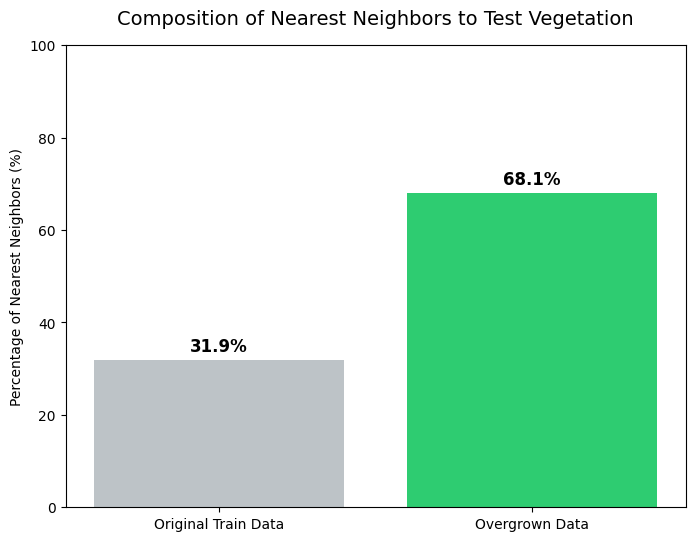

In [ ]:
combined_pool = np.vstack([train_embs, overgrown_embs])
pool_labels = np.array([0]*len(train_embs) + [1]*len(overgrown_embs)) # 0=Train, 1=Overgrown

knn = NearestNeighbors(n_neighbors=50, metric='cosine')
knn.fit(combined_pool)

distances, indices = knn.kneighbors(veg_centroid)

overgrown_hits = np.sum(pool_labels[indices])
penetration_rate = (overgrown_hits / 50) * 100

_, cluster_indices = knn.kneighbors(veg_test_embs)
total_overgrown_neighbors = np.sum(pool_labels[cluster_indices])
avg_penetration = (total_overgrown_neighbors / (len(veg_test_embs) * 50)) * 100

print(f"Top 50 Nearest Neighbors to Centroid: {penetration_rate:.1f}% are Overgrown data.")
print(f"Average Nearest Neighbors for entire Veg Cluster: {avg_penetration:.1f}% are Overgrown data.")

labels = ['Original Train Data', 'Overgrown Data']
sizes = [100 - avg_penetration, avg_penetration]
colors = ['#bdc3c7', '#2ecc71']

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.bar(labels, sizes, color=colors)
ax.set_ylabel('Percentage of Nearest Neighbors (%)')
ax.set_title('Composition of Nearest Neighbors to Test Vegetation', fontsize=14, pad=15)
ax.set_ylim(0, 100)

for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height:.1f}%', xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontweight='bold', fontsize=12)

plt.show()

# Clip classficiation

In [ ]:
from tools.clip_scene_scoring import run_clip_scene_scoring

run_clip_scene_scoring(
    train_dir=TRAIN_DIR,
    test_dir=TEST_DIR,
    clip_local=CLIP_LOCAL,
    clip_drive=DRIVE_CLIP,
    force_recompute_veg=FORCE_RECOMPUTE_VEG,
)

# Report plots

In [ ]:
!PYTHONPATH=/content/CIL_Monocular_depth {sys.executable} /content/CIL_Monocular_depth/tools/plot_distribution.py